In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm
import torch
from PIL import Image
import os
import torch.nn.functional as F
from torchinfo import summary
from torchvision.transforms import v2
import torch.nn as nn
from torch.amp import autocast, GradScaler
%matplotlib inline

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device: ", device)

In [ ]:
DATA_DIR = "classification_data"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "dev")
TEST_DIR = os.path.join(DATA_DIR, "test")

In [ ]:
img = Image.open("classification_data\\train\\n000001\\0091_01.jpg")
print(f"format: {img.format}")
print(f"size: {img.size}")
print(f"mode: {img.mode}")

In [ ]:
config = {
    "batch_size":256,
    "lr":1e-4,
    "epochs":100
}

In [ ]:
train_transforms = torchvision.transforms.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.GaussianBlur(kernel_size=1),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.RandomErasing(p=0.5, scale=(0.05, 0.05)),
    v2.Normalize(mean=[0.5116, 0.4026, 0.3519], std=[0.3073, 0.2697, 0.2587]),
])

valid_transforms = torchvision.transforms.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5116, 0.4026, 0.3519], std=[0.3073, 0.2697, 0.2587])
])

In [ ]:
train_dataset = torchvision.datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
valid_dataset = torchvision.datasets.ImageFolder(VAL_DIR, transform=valid_transforms)
test_dataset = torchvision.datasets.ImageFolder(TEST_DIR)

In [ ]:
print("Number of classes: ", len(train_dataset.classes))
print("No. of train images: ", train_dataset.__len__())
print("Shape of image: ", train_dataset[0][0].shape)

In [ ]:
# 在Linux中修改worker数为4，在Windows中修改为0，否则会报错
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    # persistent_workers=True
)

valid_loader = torch.utils.data.DataLoader(
    dataset=valid_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=4
)

In [ ]:
r, c = [5, 5]
fig, ax = plt.subplots(r, c, figsize=(15, 15))
k = 0
for data in train_loader:
    x, y = data
    for i in range(r):
        for j in range(c):
            img = x[k].numpy().transpose(1, 2, 0)
            ax[i, j].imshow(img)
            ax[i, j].axis("off")
            k += 1
    break

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample = None):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels)
        )

        self.downsample = downsample
        self.relu = nn.ReLU()
    
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        if self.downsample:
            residual = self.downsample(x)
        
        out += residual
        out = self.relu(out)

        return out

In [ ]:
class ResNet(nn.Module):
        def __init__(self, block, layers, num_classes = 7000):
            super(ResNet, self).__init__()
            self.inplanes = 64
            self.conv1 = nn.Sequential(
                            nn.Conv2d(3, 64, kernel_size = 7, stride = 2, padding = 3),
                            nn.BatchNorm2d(64),
                            nn.ReLU())
            self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)
            self.layer0 = self._make_layer(block, 64, layers[0], stride = 1)
            self.layer1 = self._make_layer(block, 128, layers[1], stride = 2)
            self.layer2 = self._make_layer(block, 256, layers[2], stride = 2)
            self.layer3 = self._make_layer(block, 512, layers[3], stride = 2)
            self.avgpool = nn.AvgPool2d(7, stride=1)
            self.fc = nn.Linear(512, num_classes)

        def _make_layer(self, block, planes, blocks, stride=1):
            downsample = None
            if stride != 1 or self.inplanes != planes:

                downsample = nn.Sequential(
                    nn.Conv2d(self.inplanes, planes, kernel_size=1, stride=stride),
                    nn.BatchNorm2d(planes),
                )
            layers = []
            layers.append(block(self.inplanes, planes, stride, downsample))
            self.inplanes = planes
            for i in range(1, blocks):
                layers.append(block(self.inplanes, planes))

            return nn.Sequential(*layers)

        def forward(self, x):
            x = self.conv1(x)
            x = self.maxpool(x)
            x = self.layer0(x)
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)

            x = self.avgpool(x)
            x = x.view(x.size(0), -1)
            x = self.fc(x)

            return x

In [ ]:
model = ResNet(ResidualBlock, [3, 4, 6, 3]).to(device)

In [ ]:
summary(model, input_size=(1, 3, 224, 224))

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
scaler = GradScaler(device=device)

In [ ]:
def train_epoch(model, optimizer, criterion, data_loader, device, scaler):
    model.train()

    train_loss = 0.0
    pred_labels = []
    true_labels = []

    for images, labels in tqdm(data_loader):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            model_out = model(images)
            Loss = criterion(model_out, labels)

        scaler.scale(Loss).backward()

        # 梯度爆炸使用梯度裁剪
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += Loss.item()

        preds = torch.argmax(model_out, dim=1)
        pred_labels.extend(preds.cpu().tolist())
        true_labels.extend(labels.cpu().tolist())

    
    train_loss /= len(data_loader)
    train_acc = accuracy_score(true_labels, pred_labels) * 100
    return train_loss, train_acc

In [ ]:
def eval(model, criterion, data_loader, device):
    model.eval()
    val_loss = 0.0
    pred_labels = []
    true_labels = []

    with torch.inference_mode():
        for images, labels in tqdm(data_loader):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            model_out = model(images)
            Loss = criterion(model_out, labels)
        
            val_loss += Loss.item()
        
            preds = torch.argmax(model_out, dim=1)
            pred_labels.extend(preds.cpu().tolist())
            true_labels.extend(labels.cpu().tolist())
    
    val_loss /= len(data_loader)
    val_acc = accuracy_score(true_labels, pred_labels) * 100
    return val_loss, val_acc

In [45]:
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []
config["epochs"]
for epoch in range(5):
    
    train_loss, train_acc = train_epoch(model, optimizer, criterion, train_loader, device, scaler)

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    val_loss, val_acc = eval(model, criterion, valid_loader, device)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch: {epoch} train_loss: {train_loss:.4f} \t train_acc: {train_acc:.4f} \t val_loss: {val_loss:.4f} \t val_acc: {val_acc:.4f}")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 0 train_loss: 1.4129 	 train_acc: 74.2857 	 val_loss: 2.8869 	 val_acc: 12.5000


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 3 train_loss: 1.4601 	 train_acc: 77.1429 	 val_loss: 2.8142 	 val_acc: 12.5000


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 4 train_loss: 1.4599 	 train_acc: 62.8571 	 val_loss: 2.7744 	 val_acc: 20.0000


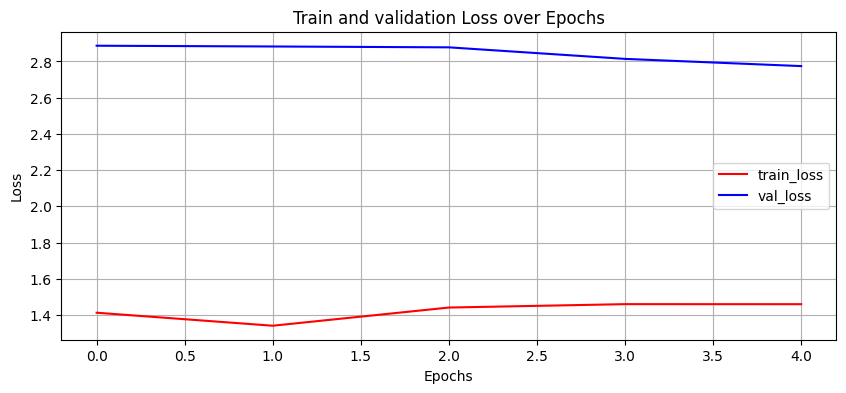

<Figure size 640x480 with 0 Axes>

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(train_loss_list, label="train_loss", color="red")
plt.plot(val_loss_list, label="val_loss", color="blue")
plt.title("Train and validation Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("Train.png", dpi=300, bbox_inches='tight')

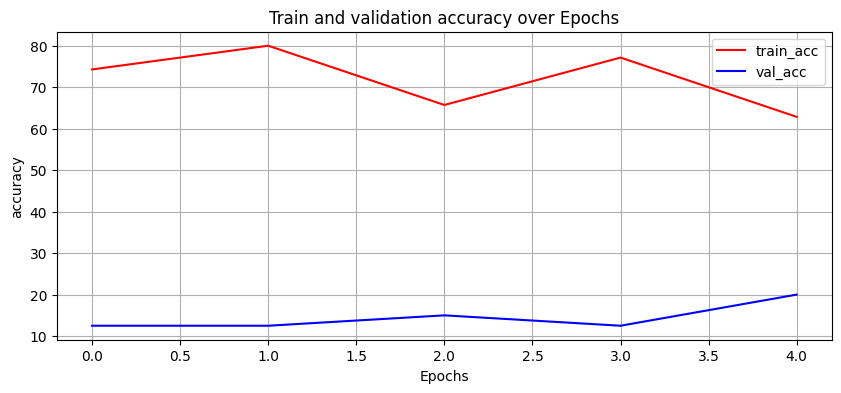

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(train_acc_list, label="train_acc", color="red")
plt.plot(val_acc_list, label="val_acc", color="blue")
plt.title("Train and validation accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.savefig("accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
torch.save(model.state_dict(), "model.pt")

In [ ]:
def test(model,dataloader):

  model.eval()
  batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, position=0, leave=False, desc='Test')
  test_results = []
  
  for i, (images) in enumerate(dataloader):
      # TODO: Finish predicting on the test set.
      images = images.to(device)

      with torch.inference_mode():
        outputs = model(images)

      outputs = torch.argmax(outputs, axis=1).detach().cpu().numpy().tolist()
      test_results.extend(outputs)
      
      batch_bar.update()
      
  batch_bar.close()
  return test_results

In [ ]:
with open("classification_early_submission.csv", "w+") as f:
    f.write("id,label\n")
    for i in range(len(test_dataset)):
        f.write("{},{}\n".format(str(i).zfill(5) + ".jpg", test_results[i]))